In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sekuestran/wacgan-ethereum-balanced/graph_data/wacgan_balanced_G1.pkl
/kaggle/input/datasets/sekuestran/wacgan-ethereum-balanced/graph_data/wgangp_balanced_G1.pkl
/kaggle/input/datasets/yhudhajuwono/ethereum-graph-dataset/first_test_graph.json
/kaggle/input/datasets/yhudhajuwono/ethereum-graph-dataset/second_test_graph.json
/kaggle/input/datasets/yhudhajuwono/ethereum-graph-dataset/graph_data/first_graph.pkl
/kaggle/input/datasets/yhudhajuwono/ethereum-graph-dataset/graph_data/second_graph.pkl
/kaggle/input/datasets/yhudhajuwono/etehereum-balanced-gd/graph_data/graphgan_balanced_G1.pkl


# Base Graph

54


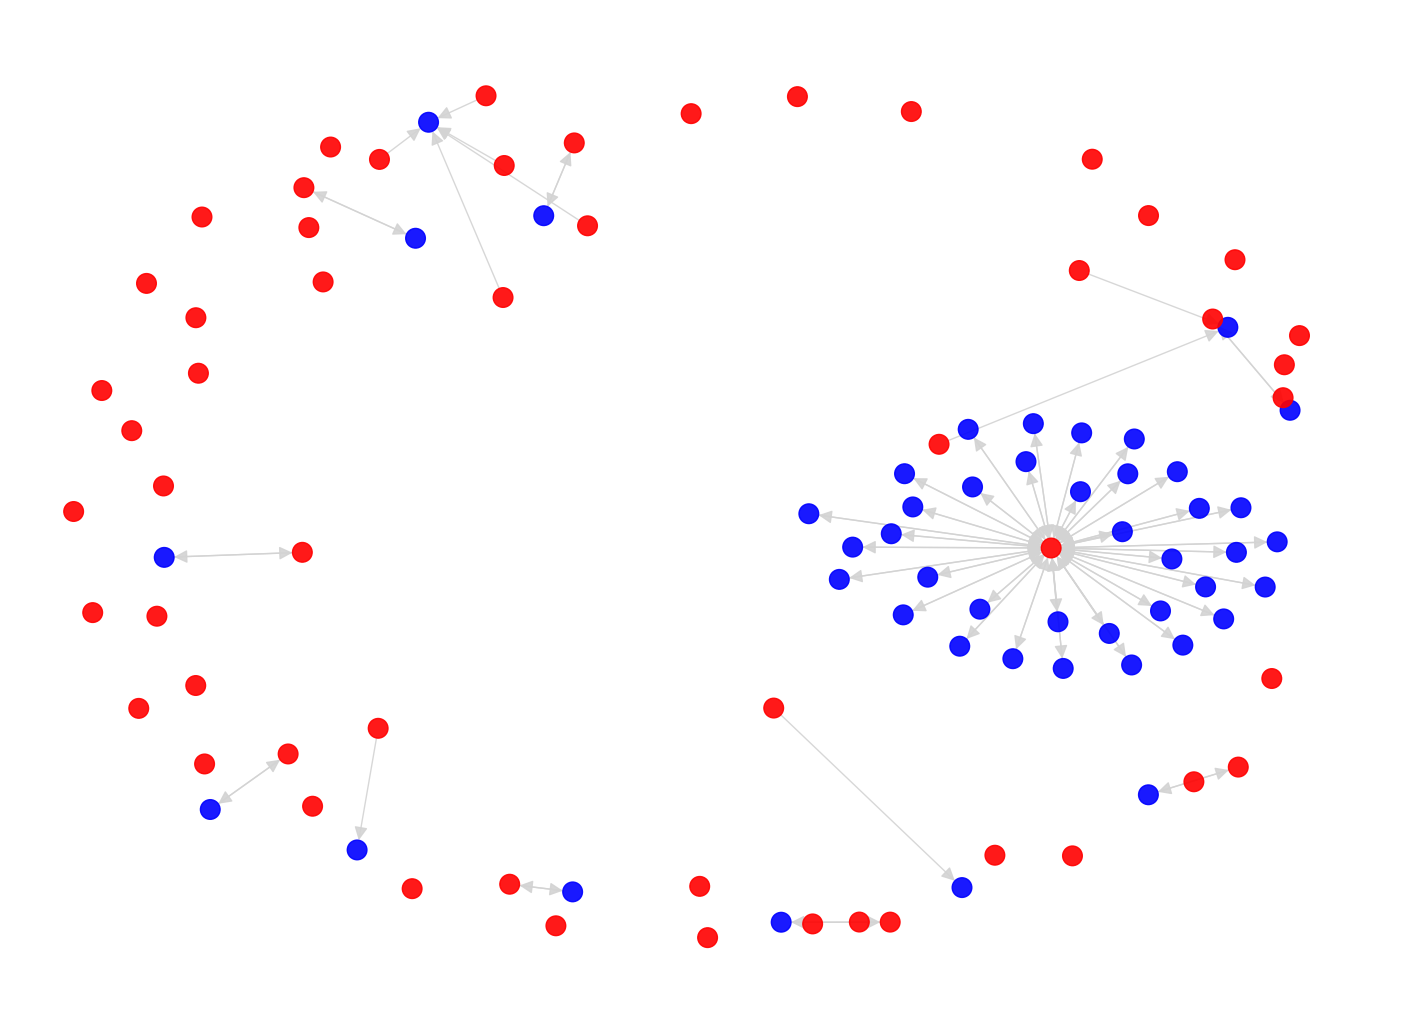

In [2]:
import json
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load data Graph
file_path = '/kaggle/input/datasets/yhudhajuwono/ethereum-graph-dataset/graph_data/first_graph.pkl'
with open(file_path, 'rb') as f:
    G = pickle.load(f)

# 3. Identifikasi & Sampling Node
fraud_nodes = [n for n, attr in G.nodes(data=True) if attr.get('is_fraud_node') == 1]
original_fraud_nodes = fraud_nodes
print(len(fraud_nodes))

selected_nodes = set()
for f_node in fraud_nodes:
    selected_nodes.add(f_node)
    # Ambil 1 tetangga non-fraud
    for neighbor in G.neighbors(f_node):
        # if G.nodes[neighbor].get('is_fraud_node') == 0:
        selected_nodes.add(neighbor)
            # break

subgraph = G.subgraph(selected_nodes)

# 4. Logika Pewarnaan
color_map = []
for node in subgraph.nodes():
    if subgraph.nodes[node].get('is_fraud_node') == 1:
        color_map.append('red')
    else:
        color_map.append('blue')       # Non-fraud

# 5. Visualisasi
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=0.3, seed=42)

nx.draw(
    subgraph, 
    pos, 
    node_color=color_map, 
    node_size=200, 
    arrowstyle='-|>', 
    arrowsize=20, 
    edge_color='lightgray',
    arrows=True,
    alpha=0.9
)

# plt.title("Merah: Fraud (di JSON), Kuning: Fraud (Lainnya), Biru: Non-Fraud")
plt.show()

# GraphGAN

[389, 524, 528, 914, 1182, 1327, 1600, 2315, 2509, 2553, 2606, 2731, 2953, 2963, 3008, 3092, 3116, 3269, 3290, 3302, 3649, 3963, 4115, 5500, 5630, 6213, 6442, 6692, 6755, 6826, 6887, 7013, 7121, 7149, 7222, 7249, 7272, 7280, 7366, 7441, 7444, 7491, 7494, 7612, 7613, 7614, 7615, 7616, 7617, 7618, 7619, 7620, 7621, 7622, 7623, 7624, 7625, 7626, 7627, 7628, 7629, 7630, 7631, 7632, 7633, 7634, 7635, 7636, 7637, 7638, 7639, 7640, 7641, 7642, 7643, 7644, 7645, 7646, 7647, 7648, 7649, 7650, 7651, 7652, 7653, 7654, 7655, 7656, 7657, 7658, 7659, 7660, 7661, 7662, 7663, 7664, 7665, 7666, 7667, 7668, 7669, 7670, 7671, 7672, 7673, 7674, 7675, 7676, 7677, 7678, 7679, 7680, 7681, 7682, 7683, 7684, 7685, 7686, 7687, 7688, 7689, 7690, 7691, 7692, 7693, 7694, 7695, 7696, 7697, 7698, 7699, 7700, 7701, 7702, 7703, 7704, 7705, 7706, 7707, 7708, 7709, 7710, 7711, 7712, 7713, 7714, 7715, 7716, 7717, 7718, 7719, 7720, 7721, 7722, 7723, 7724, 7725, 7726, 7727, 7728, 7729, 7730, 7731, 7732, 7733, 7734, 7735, 7

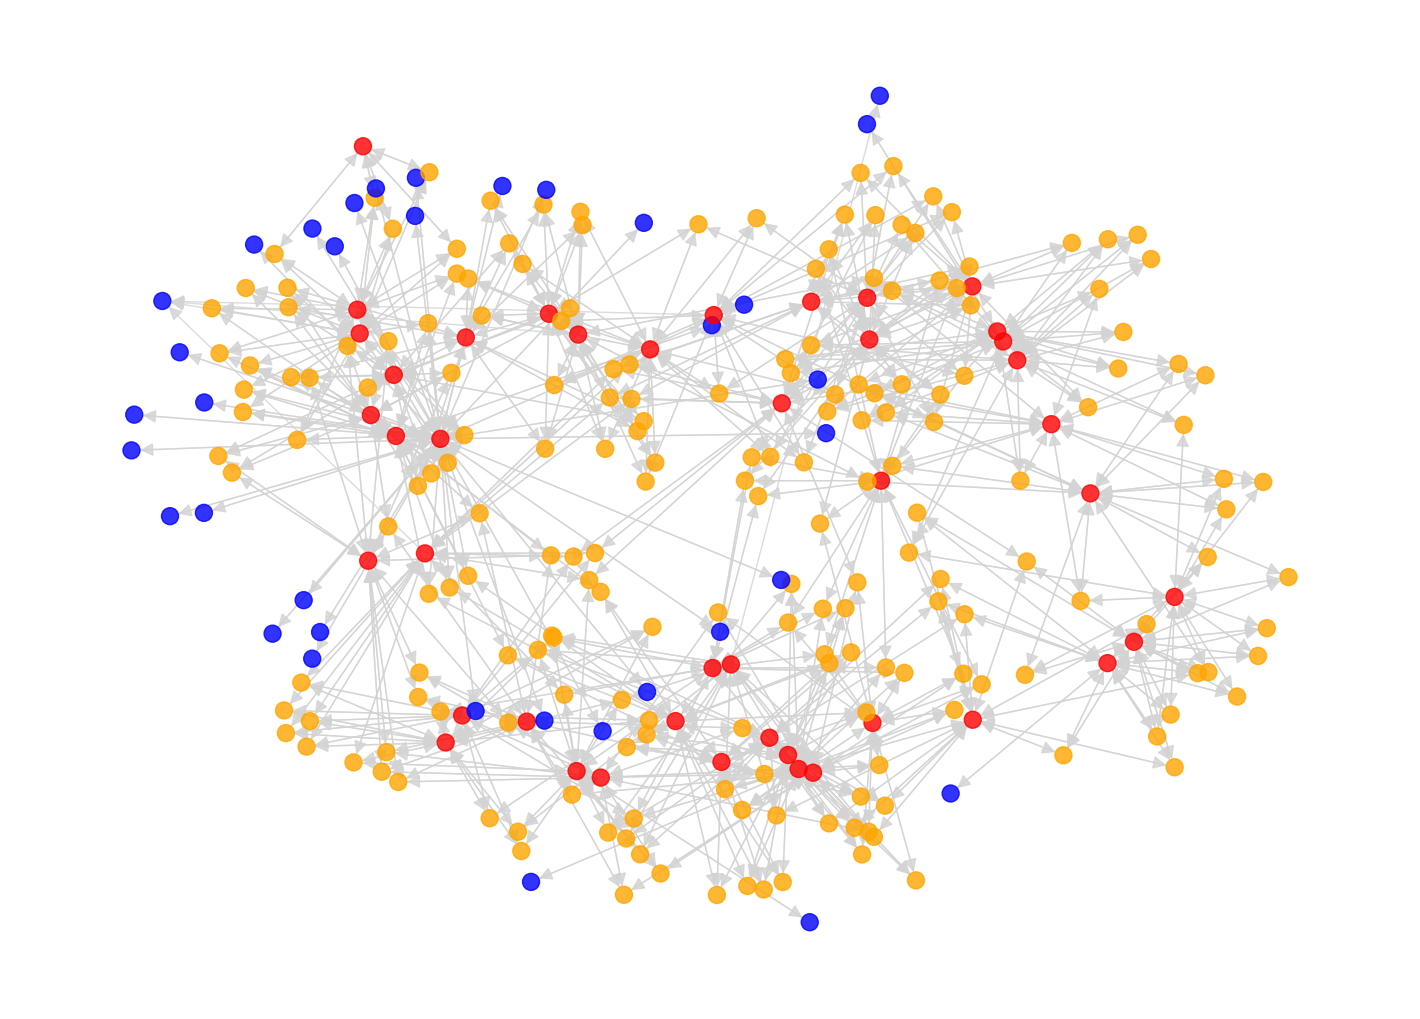

In [3]:
import json
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load data Graph
file_path = '/kaggle/input/datasets/yhudhajuwono/etehereum-balanced-gd/graph_data/graphgan_balanced_G1.pkl'
with open(file_path, 'rb') as f:
    G = pickle.load(f)

# 3. Identifikasi & Sampling Node
fraud_nodes = [n for n, attr in G.nodes(data=True) if attr.get('is_fraud_node') == 1]
print(fraud_nodes)

selected_nodes = set()
for f_node in fraud_nodes:
    selected_nodes.add(f_node)
    # Ambil 1 tetangga non-fraud
    for neighbor in G.neighbors(f_node):
        # if G.nodes[neighbor].get('is_fraud_node') == 0:
        selected_nodes.add(neighbor)
            # break 

subgraph = G.subgraph(selected_nodes)

# 4. Logika Pewarnaan
color_map = []
for node in subgraph.nodes():
    if subgraph.nodes[node].get('is_fraud_node') == 1:
        # Cek apakah ID node (dikonversi ke string) ada dalam set JSON kita
        if node in original_fraud_nodes:
            color_map.append('red')    # Fraud & ada di daftar JSON
        else:
            color_map.append('orange') # Fraud & TIDAK ada di daftar JSON
    else:
        color_map.append('blue')       # Non-fraud

# 5. Visualisasi
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=0.3, seed=42)

nx.draw(
    subgraph, 
    pos, 
    node_color=color_map, 
    node_size=150, 
    arrowstyle='-|>', 
    arrowsize=20, 
    edge_color='lightgray',
    arrows=True,
    alpha=0.8
)

# plt.title("Red: Fraud Node, Orange: Synthetic Fraud Node, Blue: Non-Fraud Node")
plt.show()

# WGANGP

154
[314, 389, 524, 528, 914, 1182, 1327, 1600, 1806, 2315, 2385, 2509, 2553, 2606, 2627, 2731, 2817, 2953, 2963, 3008, 3092, 3116, 3190, 3260, 3269, 3290, 3302, 3409, 3649, 3963, 4115, 4355, 5500, 5630, 5934, 6213, 6442, 6692, 6755, 6826, 6887, 7013, 7121, 7149, 7222, 7249, 7272, 7279, 7280, 7366, 7441, 7444, 7491, 7494, 7613, 7614, 7615, 7616, 7617, 7618, 7619, 7620, 7621, 7622, 7623, 7624, 7625, 7626, 7627, 7628, 7629, 7630, 7631, 7632, 7633, 7634, 7635, 7636, 7637, 7638, 7639, 7640, 7641, 7642, 7643, 7644, 7645, 7646, 7647, 7648, 7649, 7650, 7651, 7652, 7653, 7654, 7655, 7656, 7657, 7658, 7659, 7660, 7661, 7662, 7663, 7664, 7665, 7666, 7667, 7668, 7669, 7670, 7671, 7672, 7673, 7674, 7675, 7676, 7677, 7678, 7679, 7680, 7681, 7682, 7683, 7684, 7685, 7686, 7687, 7688, 7689, 7690, 7691, 7692, 7693, 7694, 7695, 7696, 7697, 7698, 7699, 7700, 7701, 7702, 7703, 7704, 7705, 7706, 7707, 7708, 7709, 7710, 7711, 7712]


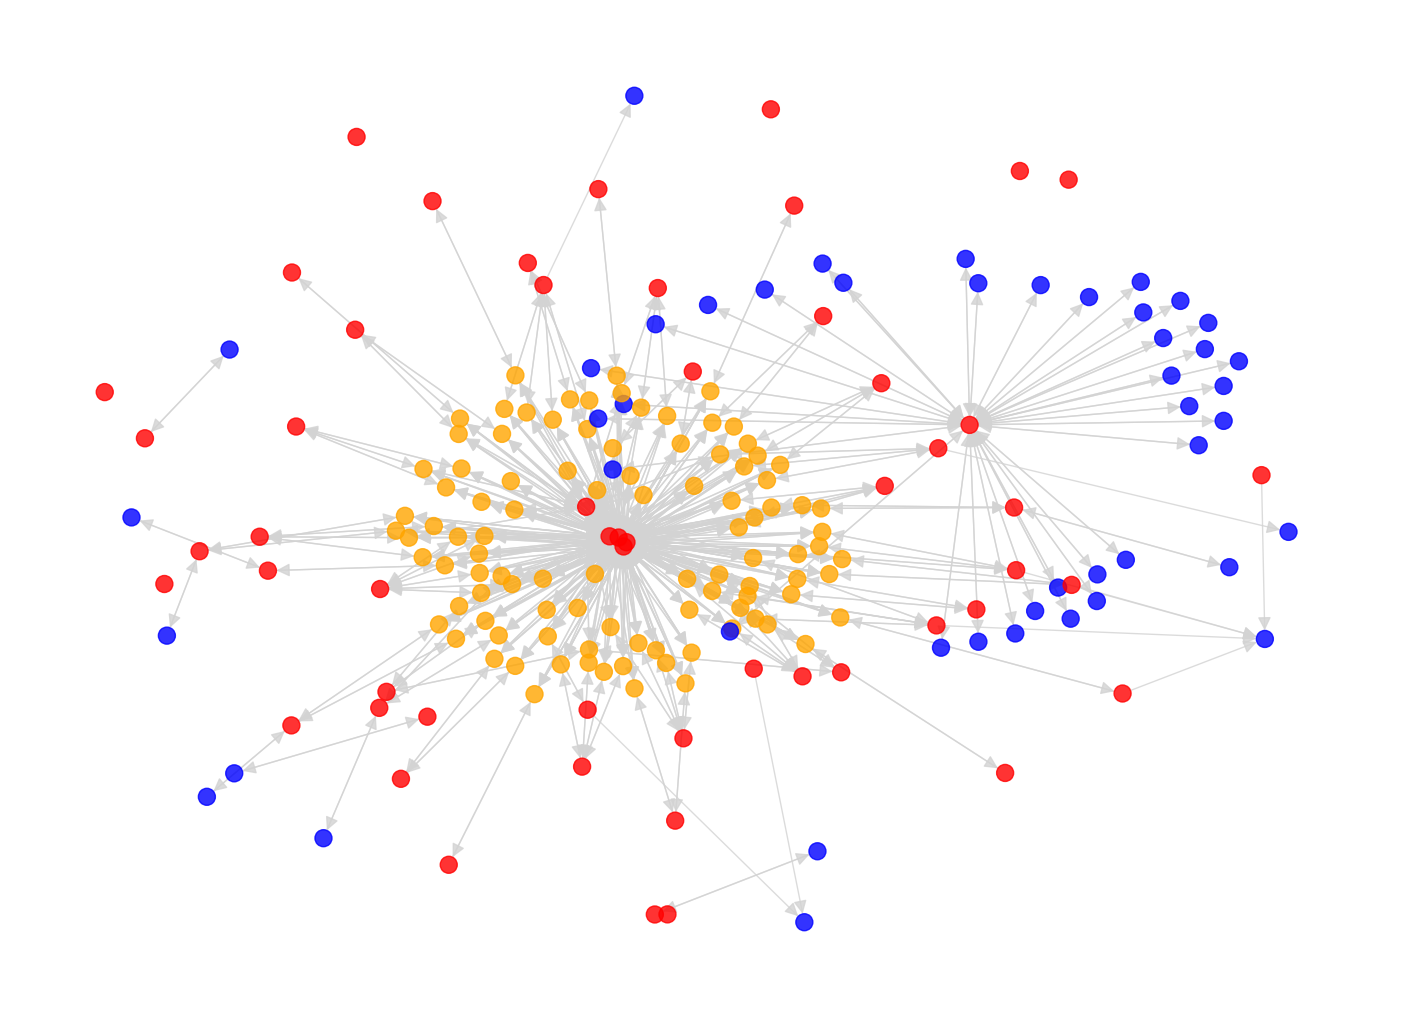

In [4]:
import json
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load data Graph
file_path = '/kaggle/input/datasets/sekuestran/wacgan-ethereum-balanced/graph_data/wgangp_balanced_G1.pkl'
with open(file_path, 'rb') as f:
    G = pickle.load(f)

# 3. Identifikasi & Sampling Node
fraud_nodes = [n for n, attr in G.nodes(data=True) if attr.get('is_fraud_node') == 1]
print(len(fraud_nodes))
print(fraud_nodes)

selected_nodes = set()
for f_node in fraud_nodes:
    selected_nodes.add(f_node)
    # Ambil 1 tetangga non-fraud
    for neighbor in G.neighbors(f_node):
        # if G.nodes[neighbor].get('is_fraud_node') == 0:
        selected_nodes.add(neighbor)
            # break 

subgraph = G.subgraph(selected_nodes)

# 4. Logika Pewarnaan
color_map = []
for node in subgraph.nodes():
    if subgraph.nodes[node].get('is_fraud_node') == 1:
        # Cek apakah ID node (dikonversi ke string) ada dalam set JSON kita
        if node in original_fraud_nodes:
            color_map.append('red')    # Fraud & ada di daftar JSON
        else:
            color_map.append('orange') # Fraud & TIDAK ada di daftar JSON
    else:
        color_map.append('blue')       # Non-fraud

# 5. Visualisasi
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=0.3, seed=42)

nx.draw(
    subgraph, 
    pos, 
    node_color=color_map, 
    node_size=150, 
    arrowstyle='-|>', 
    arrowsize=20, 
    edge_color='lightgray',
    arrows=True,
    alpha=0.8
)

# plt.title("Red: Fraud Node, Orange: Synthetic Fraud Node, Blue: Non-Fraud Node")
plt.show()

# WAGAN

304
[314, 389, 524, 528, 914, 1182, 1327, 1600, 1806, 2315, 2385, 2509, 2553, 2606, 2627, 2731, 2817, 2953, 2963, 3008, 3092, 3116, 3190, 3260, 3269, 3290, 3302, 3409, 3649, 3963, 4115, 4355, 5500, 5630, 5934, 6213, 6442, 6692, 6755, 6826, 6887, 7013, 7121, 7149, 7222, 7249, 7272, 7279, 7280, 7366, 7441, 7444, 7491, 7494, 7613, 7614, 7615, 7616, 7617, 7618, 7619, 7620, 7621, 7622, 7623, 7624, 7625, 7626, 7627, 7628, 7629, 7630, 7631, 7632, 7633, 7634, 7635, 7636, 7637, 7638, 7639, 7640, 7641, 7642, 7643, 7644, 7645, 7646, 7647, 7648, 7649, 7650, 7651, 7652, 7653, 7654, 7655, 7656, 7657, 7658, 7659, 7660, 7661, 7662, 7663, 7664, 7665, 7666, 7667, 7668, 7669, 7670, 7671, 7672, 7673, 7674, 7675, 7676, 7677, 7678, 7679, 7680, 7681, 7682, 7683, 7684, 7685, 7686, 7687, 7688, 7689, 7690, 7691, 7692, 7693, 7694, 7695, 7696, 7697, 7698, 7699, 7700, 7701, 7702, 7703, 7704, 7705, 7706, 7707, 7708, 7709, 7710, 7711, 7712, 7713, 7714, 7715, 7716, 7717, 7718, 7719, 7720, 7721, 7722, 7723, 7724, 7725

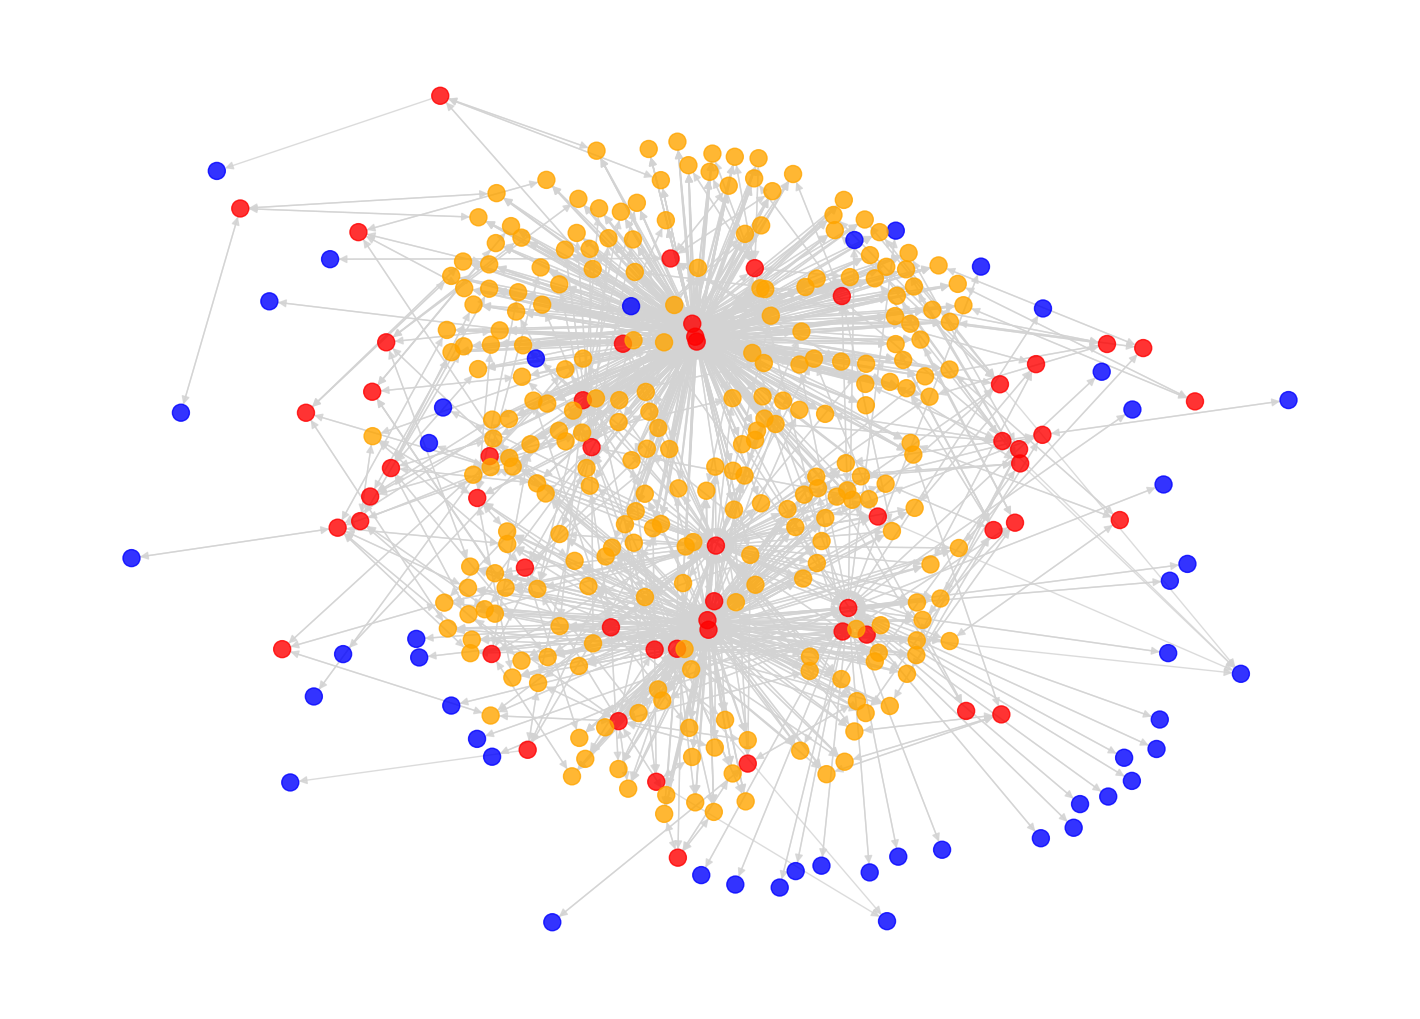

In [5]:
import json
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load data Graph
file_path = '/kaggle/input/datasets/sekuestran/wacgan-ethereum-balanced/graph_data/wacgan_balanced_G1.pkl'
with open(file_path, 'rb') as f:
    G = pickle.load(f)

# 3. Identifikasi & Sampling Node
fraud_nodes = [n for n, attr in G.nodes(data=True) if attr.get('is_fraud_node') == 1]
print(len(fraud_nodes))
print(fraud_nodes)

selected_nodes = set()
for f_node in fraud_nodes:
    selected_nodes.add(f_node)
    # Ambil 1 tetangga non-fraud
    for neighbor in G.neighbors(f_node):
        # if G.nodes[neighbor].get('is_fraud_node') == 0:
        selected_nodes.add(neighbor)
            # break 

subgraph = G.subgraph(selected_nodes)

# 4. Logika Pewarnaan
color_map = []
for node in subgraph.nodes():
    if subgraph.nodes[node].get('is_fraud_node') == 1:
        # Cek apakah ID node (dikonversi ke string) ada dalam set JSON kita
        if node in original_fraud_nodes:
            color_map.append('red')    # Fraud & ada di daftar JSON
        else:
            color_map.append('orange') # Fraud & TIDAK ada di daftar JSON
    else:
        color_map.append('blue')       # Non-fraud

# 5. Visualisasi
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=0.3, seed=42)

nx.draw(
    subgraph, 
    pos, 
    node_color=color_map, 
    node_size=150, 
    arrowstyle='-|>', 
    arrowsize=12, 
    edge_color='lightgray',
    arrows=True,
    alpha=0.8
)

# plt.title("Red: Fraud Node, Orange: Synthetic Fraud Node, Blue: Non-Fraud Node")
plt.show()